# Context Vector Analysis in LLMs: Clustering and Loglog Plot
## dataset: General, Wikipedia, 2000 sentences
## Workflow
1. Init: Model & Data
  - Load any complex LLM (like LLAMA) and analysis it's architecture
  - Get a dataset containing 2000 continuous sentences. Pick a book with specific genre, Love or Mystery.
2. Embedding Analysis
  - Now retrieve the sentence embedding by getting the last vector in the final transformer. Or the input to the Fully connected layer (as discussed in the meeting)
3. Similarity Analysis
  - Do the similar analysis as before.
  - Do clustering using the sentence embedding and count the number of sentences in each cluster. Add the number of sentence on each group as a sanity check.
4. Plotting
  - Save the count in a vector. Rearrange them, and plot the count in y-axis and matrix index in the x-axis.
  - Also plot the log log plot using the count matrix.
  - Fit the log log plot with linear line and get the slope.

### 1. Initialization
- Model load
- Data analysis

In [1]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 5.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is i

In [2]:
from datasets import load_dataset
import nltk
from tqdm import tqdm

nltk.download('punkt')

ds = load_dataset("wikimedia/wikipedia", "20231101.en", streaming=True)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/131k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

In [5]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [6]:
sentences = []

stream = ds["train"]

target_sentences = 2000

for example in tqdm(stream):
    text = example["text"]
    article_sentences = nltk.sent_tokenize(text)

    sentences.extend(article_sentences)

    if len(sentences) >= target_sentences:
        sentences = sentences[:target_sentences]
        break

5it [00:01,  3.57it/s]


In [7]:
print(len(sentences))

2000


In [9]:
import json

with open("wikipedia_2000_sentences.json", "w", encoding = "utf-8") as f:
  json.dump(sentences, f, ensure_ascii=False, indent=4)

In [10]:
# Load Model
import torch
from transformers import BertTokenizer, BertModel

model_name = "bert-base-uncased"


tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name, output_hidden_states=True)
model.eval()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

### 2. Features in LLMs Analysis

In [11]:
## define the function that extracts Features

def get_features(sentence, model, tokenizer, layer_indices=[-1, -4]):
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, padding=True, max_length=128)

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)  # Ensure hidden states are returned

    hidden_states = outputs.hidden_states  # Extract all hidden states

    # Extract final layer embedding (CLS token representation)
    final_layer_emb = hidden_states[layer_indices[0]][:, 0, :].squeeze(0).cpu().numpy()

    # Extract intermediate layer embedding (e.g., -4th layer)
    intermediate_layer_emb = hidden_states[layer_indices[1]][:, 0, :].squeeze(0).cpu().numpy()

    return final_layer_emb, intermediate_layer_emb

In [12]:
import numpy as np

batch_size = 32
num_batches = len(sentences) // batch_size + (len(sentences) % batch_size != 0)

final_embeddings = []
intermediate_embeddings = []

for i in range(num_batches):
    batch = sentences[i * batch_size: (i + 1) * batch_size]

    # Get embeddings from model
    batch_final_emb, batch_inter_emb = zip(*[get_features(sent, model, tokenizer) for sent in batch])

    final_embeddings.extend(batch_final_emb)
    intermediate_embeddings.extend(batch_inter_emb)

final_embeddings = np.array(final_embeddings)
intermediate_embeddings = np.array(intermediate_embeddings)

print("Final embedding shape:", final_embeddings.shape)
print("Intermediate embedding shape:", intermediate_embeddings.shape)

Final embedding shape: (2000, 768)
Intermediate embedding shape: (2000, 768)


### 3. Similarity Analysis
- Cosine Similarity-based Grouping

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

final_cos_similar = cosine_similarity(final_embeddings)
intermediate_cos_similar = cosine_similarity(intermediate_embeddings)

In [14]:
# Simple Greedy Approcah
def grouping(cos_similar, n, thres):
  groups = []
  visited = set()

  for i in range(n):
    if i in visited:
      continue

    group = [i]
    visited.add(i)

    for j in range(n):
      if j not in visited and cos_similar[i][j] >= thres:
        group.append(j)
        visited.add(j)

    groups.append(group)

  return groups


# graph-based grouping (connected componenets) - clustering
import networkx as nx

def graph_based_grouping(cos_similar, n, thres):
  graph = nx.Graph()

  graph.add_nodes_from(range(n))

  for i in range(n):
    for j in range(i+1, n):
      if cos_similar[i][j] >= thres:
        graph.add_edge(i, j)

  groups = [list(component) for component in nx.connected_components(graph)]

  return groups


# Clustering using DBSCAN
from sklearn.cluster import DBSCAN

def clustering_grouping(embedding, thres):
  eps = 1 - thres
  clustering = DBSCAN(eps=eps, min_samples=2, metric="cosine").fit(embedding)
  labels = clustering.labels_

  # print("The number of clusters:", len(set(labels))-(1 if -1 in labels else 0))

  groups = {}
  for idx, label in enumerate(labels):
    if label not in groups:
      groups[label] = []
    groups[label].append(idx)
  return list(groups.values())

In [15]:
print("Cosine Similarity")
print(np.round(final_cos_similar[:5, :5], 2))

Cosine Similarity
[[1.   0.82 0.84 0.71 0.75]
 [0.82 1.   0.84 0.73 0.84]
 [0.84 0.84 1.   0.76 0.83]
 [0.71 0.73 0.76 1.   0.75]
 [0.75 0.84 0.83 0.75 1.  ]]


In [16]:
n = len(sentences)
thres = 0.9

greedy_final = grouping(final_cos_similar, n, thres)
greedy_inter = grouping(intermediate_cos_similar, n, thres)

graph_final = graph_based_grouping(final_cos_similar, n, thres)
graph_inter = graph_based_grouping(intermediate_cos_similar, n, thres)


dbscan_final = clustering_grouping(final_embeddings, thres)
dbscan_inter = clustering_grouping(intermediate_embeddings, thres)

In [17]:
print(f"Greedy Clustering (Final Layer): {len(greedy_final)} clusters")
print(f"Greedy Clustering (Intermediate Layer): {len(greedy_inter)} clusters")

print(f"Graph-based Clustering (Final Layer): {len(graph_final)} clusters")
print(f"Graph-based Clustering (Intermediate Layer): {len(graph_inter)} clusters")

print(f"DBSCAN Clustering (Final Layer): {len(dbscan_final)} clusters")
print(f"DBSCAN Clustering (Intermediate Layer): {len(dbscan_inter)} clusters")

Greedy Clustering (Final Layer): 1359 clusters
Greedy Clustering (Intermediate Layer): 548 clusters
Graph-based Clustering (Final Layer): 1025 clusters
Graph-based Clustering (Intermediate Layer): 185 clusters
DBSCAN Clustering (Final Layer): 101 clusters
DBSCAN Clustering (Intermediate Layer): 17 clusters


- Count

In [18]:
def get_count(groups):
  group_counts = []
  word_counts = []

  for group in groups:
    group_counts.append(len(group))

    unique_words = set() # prevent duplicates
    for idx in group:
      unique_words.update(sentences[idx].split())
    word_counts.append(len(unique_words))
  return group_counts, word_counts # num of sentence per group, num of word per group

In [19]:
print("--Greedy Grouping--")
greedy_group_counts_final, greedy_word_counts_final = get_count(greedy_final)
greedy_group_counts_inter, greedy_word_counts_inter = get_count(greedy_inter)
print("Final layers' Group Counts of first 5th group:", greedy_group_counts_final[:5])
print("Intermediate layers' Group Counts of first 5th group:", greedy_group_counts_inter[:5])


print("--Graph Grouping--")
graph_group_counts_final, graph_word_counts_final = get_count(graph_final)
graph_group_counts_inter, graph_word_counts_inter = get_count(graph_inter)

print("Final layers' Group Counts of first 5th group:", graph_group_counts_final[:5])
print("Intermediate layers' Group Counts of first 5th group:", graph_group_counts_inter[:5])


print("--dbscan Grouping--")
dbscan_group_counts_final, dbscan_word_counts_final = get_count(dbscan_final)
dbscan_group_counts_inter, dbscan_word_counts_inter = get_count(dbscan_inter)

print("Final layers' Group Counts of first 5th group:", dbscan_group_counts_final[:5])
print("Intermediate layers' Group Counts of first 5th group:", dbscan_group_counts_inter[:5])

--Greedy Grouping--
Final layers' Group Counts of first 5th group: [4, 9, 32, 1, 3]
Intermediate layers' Group Counts of first 5th group: [9, 11, 122, 1, 17]
--Graph Grouping--
Final layers' Group Counts of first 5th group: [670, 1, 1, 1, 1]
Intermediate layers' Group Counts of first 5th group: [1755, 1, 4, 1, 1]
--dbscan Grouping--
Final layers' Group Counts of first 5th group: [670, 925, 2, 3, 3]
Intermediate layers' Group Counts of first 5th group: [1755, 169, 4, 2, 4]


In [20]:
print("sanity check using the number of sentences in each group")
print("The total number of sentences in the Final layers:", sum(greedy_group_counts_final))
print("The total number of sentences in the Intermediate layers:", sum(greedy_group_counts_inter))

print("Sanity check result:", n == sum(greedy_group_counts_final) == sum(greedy_group_counts_inter))

sanity check using the number of sentences in each group
The total number of sentences in the Final layers: 2000
The total number of sentences in the Intermediate layers: 2000
Sanity check result: True


### Plotting
1. Plot
2. Loglog Plot
3. Linear Regression

In [21]:
def rearrange_decreasing_order(counts_vector):
  counts_vector = np.array(counts_vector)
  sorted_indices = np.argsort(-counts_vector)
  sorted_sent_counts = counts_vector[sorted_indices]
  return sorted_sent_counts

1. Count-based Plot

In [23]:
import matplotlib.pyplot as plt

def plotting(flag, sorted_sent_counts, model):
  if flag:
    detail = "[Final layer]"
  else:
    detail = "[Intermediate layer]"
  # x-axis
  plt.figure(figsize=(16,8))
  plt.plot(range(len(sorted_sent_counts)), sorted_sent_counts, marker='o', linestyle="-")


  plt.xlabel("Groupd Index (Sorted)")
  plt.ylabel("The Number of Sentences per group")
  plt.title(detail + " The Number of Sentences per Group - " + model)
  plt.grid(True)

  plt.show()

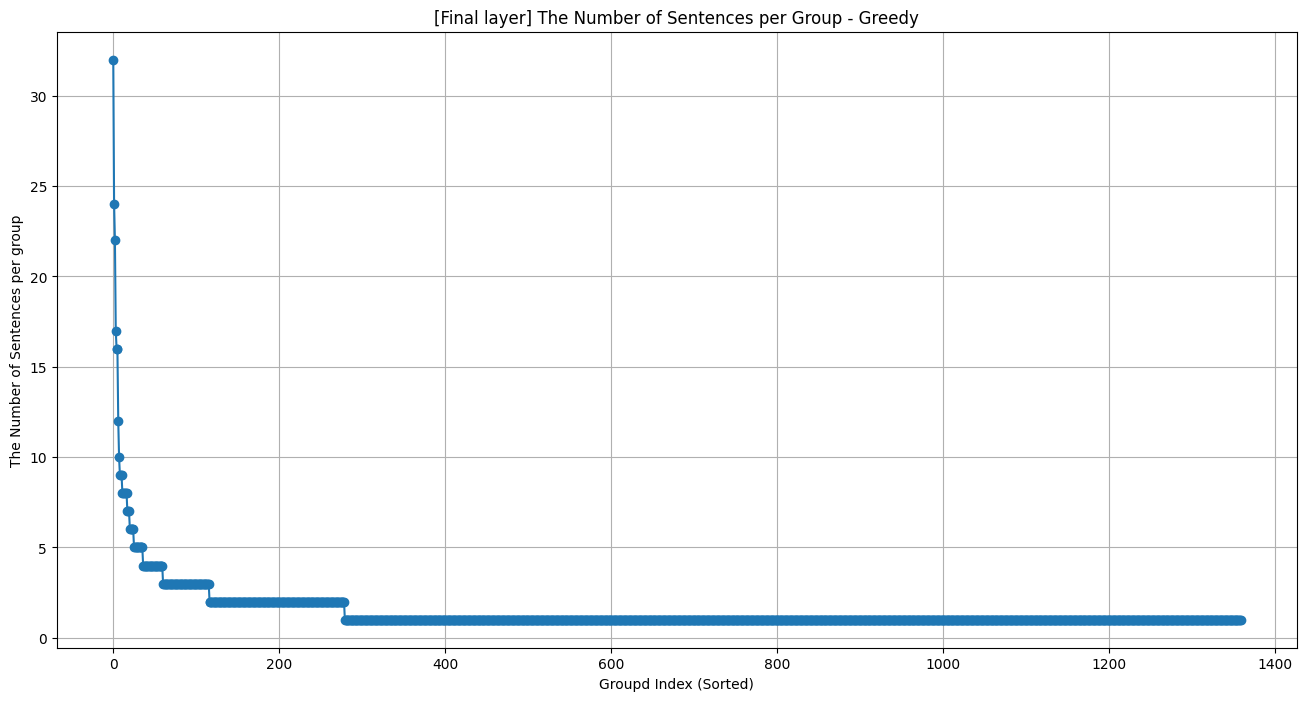

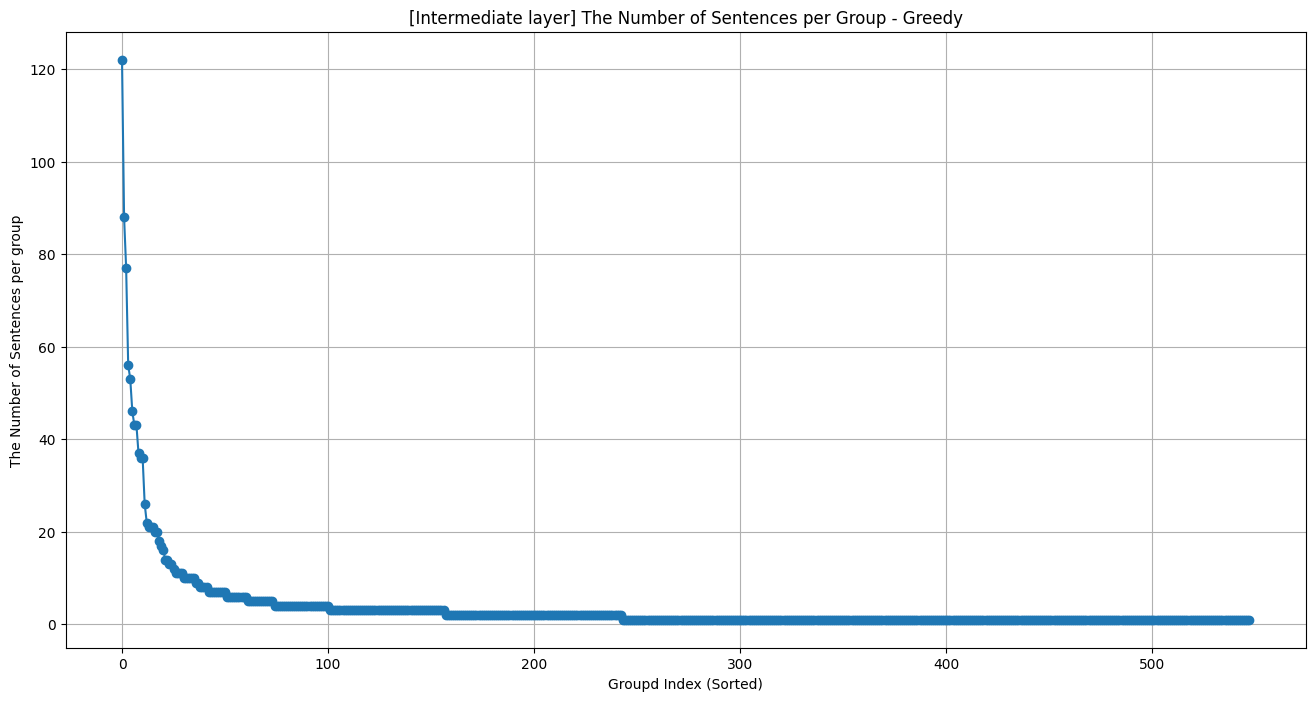

In [24]:
# rearrange in decreaing order (ranking)
sorted_sent_counts_final = rearrange_decreasing_order(greedy_group_counts_final)
sorted_sent_counts_inter = rearrange_decreasing_order(greedy_group_counts_inter)

plotting(True, sorted_sent_counts_final, "Greedy")
plotting(False, sorted_sent_counts_inter, "Greedy")

2. Loglog Plot

In [25]:
# Also plot the log log plot using the count matrix.
def loglog_plotting(flag, sorted_sent_counts, model):
  if flag:
    detail = "[Final layer]"
  else:
    detail = "[Intermediate layer]"
  plt.figure(figsize=(16,8))
  plt.loglog(range(len(sorted_sent_counts)), sorted_sent_counts, marker="o", linestyle="-")

  plt.xlabel("Groupd Index (Log Scale)")
  plt.ylabel("The Number of Sentences per group (Log Scale)")
  plt.title(detail + "Log-Log Plot of The Number of Sentences per group - " + model)
  plt.grid(True, which="both", linestyle="--")

  plt.show()

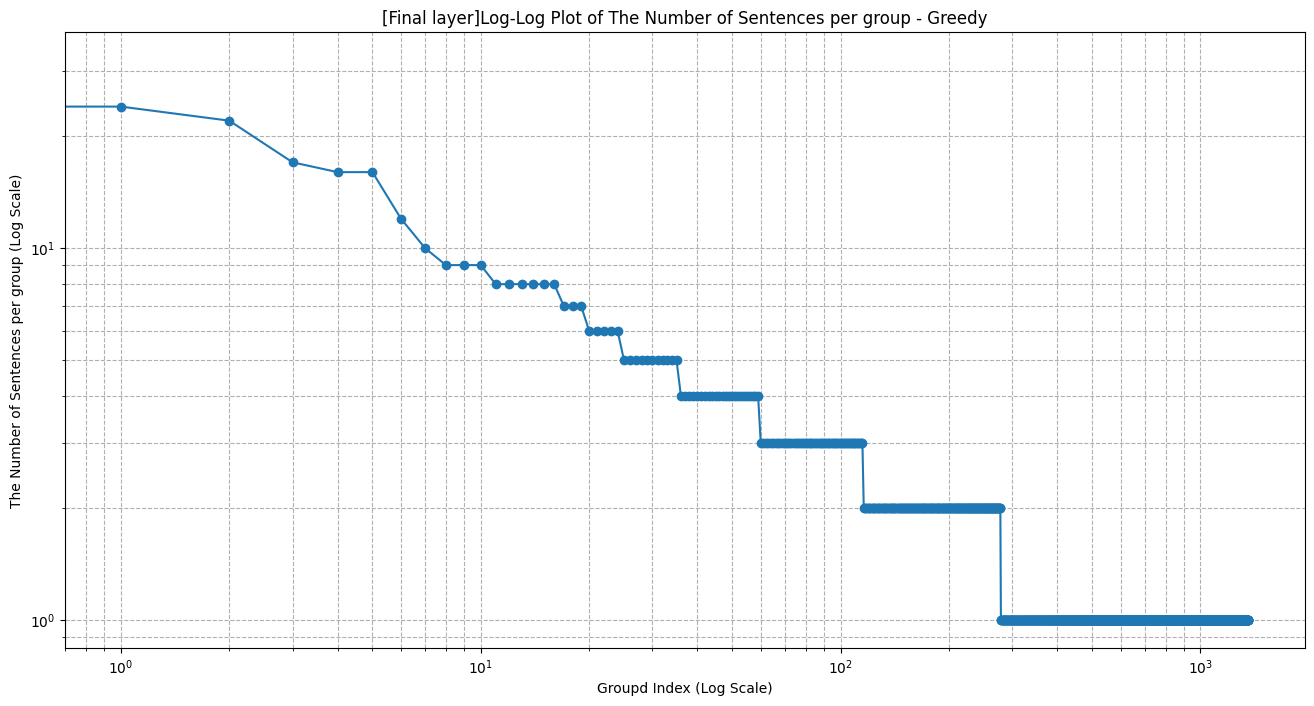

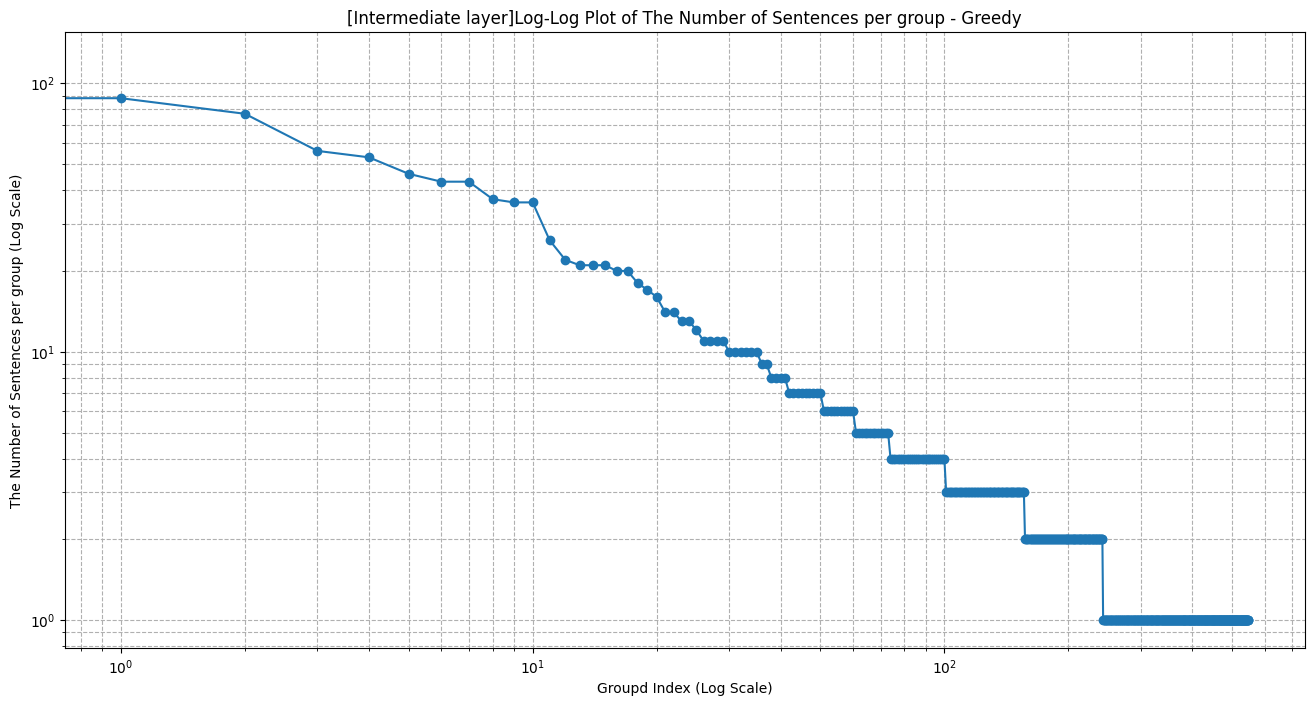

In [26]:
loglog_plotting(True, sorted_sent_counts_final, "Greedy")
loglog_plotting(False, sorted_sent_counts_inter, "Greedy")

3. Linear Regression

In [27]:
from scipy.stats import linregress

def linear_regression(sorted_sent_counts):
  x = np.log10(np.arange(1, len(sorted_sent_counts)+1))
  y = np.log10(sorted_sent_counts)

  # linear regression
  slope, intercept, r_val, p_val, std_err = linregress(x, y)

  # regression prediction
  y_pred = slope * x + intercept

  return x, y, slope, intercept, r_val, p_val, y_pred

In [28]:
def return_linear_regression_result(flag, sorted_sent_counts):
  if flag:
    detail = "[Final layer]"
  else:
    detail = "[Intermediate layer]"

  x, y, slope, intercept, r_val, p_val, y_pred = linear_regression(sorted_sent_counts)

  print(detail + "Linear Regression Prediction: y = slope * x + intercept")
  print(f"y ={slope:.2f}x + {intercept:.2f}")

  print(f"Linear Regression Results:")
  print(f"   - Slope: {slope:.4f}")
  print(f"   - Intercept: {intercept:.4f}")
  print(f"   - R-squared: {r_val**2:.4f}")
  print(f"   - P-value: {p_val:.4e}")

In [29]:
## Greedy
print("-- Greedy --")
return_linear_regression_result(True, sorted_sent_counts_final)
print()
return_linear_regression_result(False, sorted_sent_counts_inter)

-- Greedy --
[Final layer]Linear Regression Prediction: y = slope * x + intercept
y =-0.43x + 1.26
Linear Regression Results:
   - Slope: -0.4329
   - Intercept: 1.2591
   - R-squared: 0.8391
   - P-value: 0.0000e+00

[Intermediate layer]Linear Regression Prediction: y = slope * x + intercept
y =-0.89x + 2.33
Linear Regression Results:
   - Slope: -0.8923
   - Intercept: 2.3267
   - R-squared: 0.9604
   - P-value: 0.0000e+00


In [30]:
def linear_regression_plotting(flag, sorted_sent_counts, model):
  if flag:
    detail = "[Final layer]"
  else:
    detail = "[Intermediate layer]"

  x, y, slope, intercept, r_val, p_val, y_pred = linear_regression(sorted_sent_counts)

  plt.figure(figsize=(16,8))
  plt.scatter(x, y, label="Sentences counts (Log-Log)", alpha=0.8, marker="o")
  plt.plot(x, y_pred, color = "red", label=f"Linear Fit: y={slope:.2f}x + {intercept:.2f}")
  plt.text(0.1, 1.2, f"$R^2$ = {r_val**2:.4f}", fontsize=14, color="black")

  plt.xlabel("Group Index (Log scale)")
  plt.ylabel("The Number of Sentences per group (Log scale)")
  plt.title(detail + "Linear Regression on Log-Log Scale - " + model)
  plt.legend()
  plt.grid(True)

  plt.show()

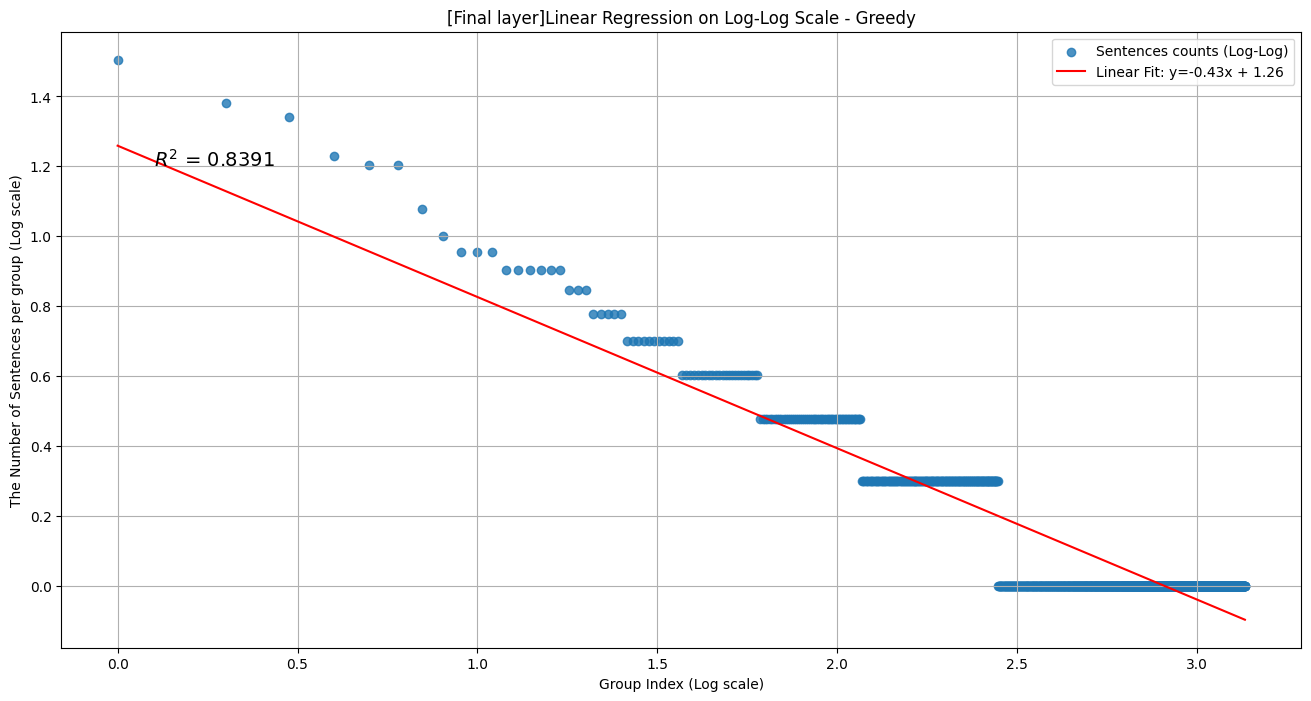

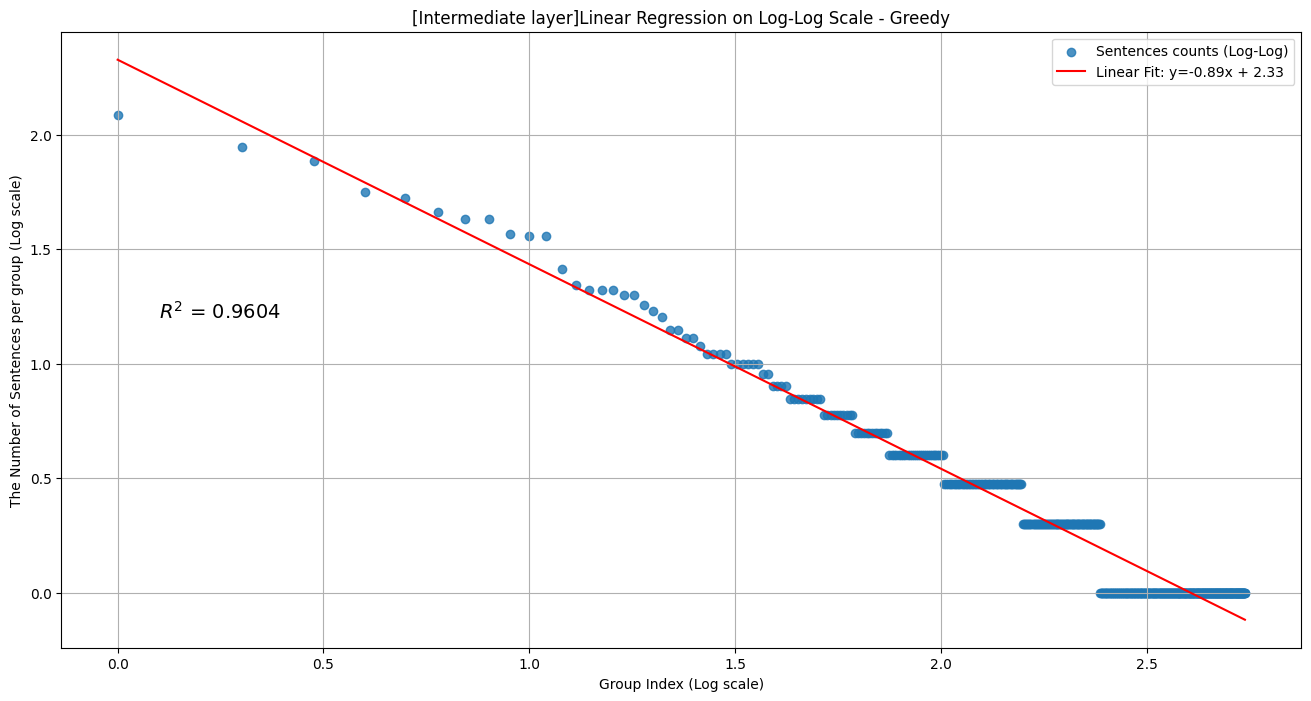

In [31]:
linear_regression_plotting(True, sorted_sent_counts_final, "Greedy")
linear_regression_plotting(False, sorted_sent_counts_inter, "Greedy")